<a href="https://colab.research.google.com/github/JungYeoni/study_torch/blob/main/DL/ANN/%EB%8B%A4%EC%B8%B5_%ED%8D%BC%EC%85%89%ED%8A%B8%EB%A1%A0%EC%9C%BC%EB%A1%9C_MNIST_%EB%B6%84%EB%A5%98%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 다층 퍼셉트론으로 MNIST 분류하기

- 소프트맥스로 MNIST 데이터 분류 -> 입력층과 출력층만 존재
- 은닉층을 추가로 넣어 다층 퍼셉트론 구현하기

## 데이터 로드하기

In [28]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [29]:
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)

In [30]:
mnist.data[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

In [31]:
# 첫번째 샘플의 레이블을 출력
mnist.target[0]

'5'

--> 현재는 문자열 타입

In [32]:
# 레이블 데이터 타입을 정수형으로 변환
mnist.target = mnist.target.astype(np.int8)

In [33]:
# 이미지 데이터를 0-255 범위 0-1 범위로 정규화
X = mnist.data / 255
y = mnist.target

In [34]:
# 정규화된 첫 번째 이미지 데이터 출력
X[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [35]:
# 첫 번째 이미지의 레이블 출력
y[0]

np.int8(5)

이 이미지의 데이터 레이블은 5이다



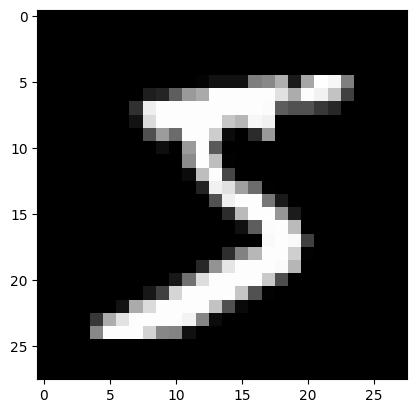

In [36]:
# 첫 번째 샘플 시각화 후 레이블 출력
plt.imshow(X[0].reshape(28, 28), cmap='gray')
print('이 이미지의 데이터 레이블은 {:.0f}이다\n'.format(y[0]))

## 훈련 데이터와 테스트 데이터의 분리

In [37]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [38]:
# 훈련 데이터와 테스트 데이터로 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/7, random_state=0)

In [39]:
# 텐서로 변환 후
X_train = torch.Tensor(X_train)
X_test = torch.Tensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

# TensorDataset을 사용하여 데이터셋 구성
ds_train = TensorDataset(X_train, y_train)
ds_test = TensorDataset(X_test, y_test)

# Dataloader 객체 생성
loader_train = DataLoader(ds_train, batch_size=64, shuffle=True)
loader_test = DataLoader(ds_test, batch_size=64, shuffle=False)

*복습
`DataLoader`의 역할
- Dataset을 받아서
- batch 단위로 잘라주고
- 섞어주고 (shuffle)
- 반복 가능하게 만들어줌

## 다층 퍼셉트론

In [40]:
from torch import nn
from torch import optim

In [41]:
model = nn.Sequential()
model.add_module('fc1', nn.Linear(28*28*1, 100))
model.add_module('relu1', nn.ReLU())
model.add_module('fc2', nn.Linear(100, 100))
model.add_module('relu2', nn.ReLU())
model.add_module('f3', nn.Linear(100, 10))

print(model)

Sequential(
  (fc1): Linear(in_features=784, out_features=100, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=100, out_features=100, bias=True)
  (relu2): ReLU()
  (f3): Linear(in_features=100, out_features=10, bias=True)
)


In [42]:
# 오차함수 선택
loss_fn = nn.CrossEntropyLoss()

# 가중치를 학습하기 위한 최적화 기법 선택
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [43]:
# 총 3번의 에포크 동안 모델 학습
epochs = 3

for epoch in range(epochs):
  for data, targets in loader_train:
    optimizer.zero_grad()
    y_pred = model(data)
    loss = loss_fn(y_pred, targets)
    loss.backward()
    optimizer.step()

  print('Epoch {:4d}/{} Cost: {:.6f}'.format(
      epoch + 1, 3, loss.item()
  ))

Epoch    1/3 Cost: 0.104828
Epoch    2/3 Cost: 0.416443
Epoch    3/3 Cost: 0.059396


In [46]:
model.eval() # 신경망을 추론 모드로 전환
correct = 0

# 데이터로더에서 미니배치를 하나씩 꺼내 추론을 수행
with torch.no_grad():
  for data, target in loader_test:
    outputs = model(data) # 데이터를 입력하고 출력을 계산 -> 각 클래스에 대한 점수(logits)

    # 추론 계산
    _, predicted = torch.max(outputs.data, 1) # 확률이 가장 높은 레이블이 무엇인지 계산

    # 정답과 일치한 경우 정답 카운트를 증가
    correct += predicted.eq(target.data.view_as(predicted)).sum()

  # 정확도 출력
  data_num = len(loader_test.dataset) # 데이터 총 건수
  print('\n테스트 데이터에서 예측 정확도: {}/{} ({:.0f}%)\n'.format(correct, data_num, 100. * correct / data_num))



테스트 데이터에서 예측 정확도: 9557/10000 (96%)




```python
_, predicted = torch.max(outputs.data, 1) # 확률이 가장 높은 레이블이 무엇인지 계산
```

-


예측 결과: 2
이 이미지 데이터 정답 레이블은 2 입니다.


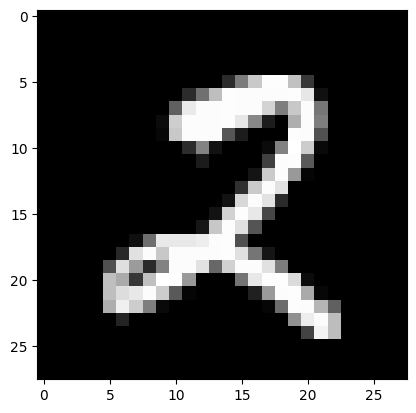

In [49]:
# 임의의 데이터에 대해 특정 인덱스의 테스트 이미지를 모델에 전달하여 예측 결과 얻기
index = 2018

model.eval() # 신경망을 추론 모드로 전환
data = X_test[index] #
output = model(data)
_, predicted = torch.max(output.data, 0) # 확률이 가장 높은 레이블이 무엇인지 계산

print('예측 결과: {}'.format(predicted))
X_test_show = (X_test[index]).numpy()
plt.imshow(X_test_show.reshape(28, 28), cmap='gray')
print('이 이미지 데이터 정답 레이블은 {:.0f} 입니다.'.format(y_test[index]))